In [58]:
##################
# Library imports #
###################

import numpy as np
import matplotlib.pyplot as plt

from matplotlib import animation
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm

from joblib import Parallel, delayed, dump

from tenpy.networks.mps import MPS
from tenpy.models.model import CouplingMPOModel
from tenpy.networks import site
from tenpy.algorithms.dmrg import TwoSiteDMRGEngine
from tenpy.algorithms import tdvp

In [21]:
################################################################
# Define the time-dependent spinless interacting fermion model #
################################################################

class time_dependent_Hubbard(CouplingMPOModel):

    default_lattice = 'Chain' # Using ladder to represent sample + probe
    force_default_lattice = True # Ensure we always use the ladder lattice

    def init_sites(self, model_params): 
        sites = site.SpinHalfFermionSite(cons_N='N', cons_Sz='Sz') # Sample site

        # Construct costum opertors

        Id = sites.get_op('Id')
        Nu = sites.get_op('Nu')
        Nd = sites.get_op('Nd')
        NuNd = sites.get_op('NuNd')
        
        sites.add_op('d', NuNd)
        h = sites.multiply_operators([Id - Nu, Id - Nd])
        sites.add_op('h', h)
        
        return sites # Return list of site objects

    def init_terms(self, model_params):

        # Extract parameters
        J = model_params.get('J', 1.0)
        U = model_params.get('U', 10.0)

        mu = model_params.get('mu', 0.0)
 
        # Hopping within the sample
        self.add_coupling(-J, 0, 'Cdu', 0, 'Cu', [1], plus_hc=True)
        self.add_coupling(-J, 0, 'Cdd', 0, 'Cd', [1], plus_hc=True)

        # Onsite interaction in the sample
        self.add_onsite(U, 0, 'NuNd')

        # Chemical potential on the sample
        self.add_onsite(mu, 0, 'Ntot')

#############
# Functions #
#############

def correlation(psi, model):

    # Sample sites
    sample_sites = model.lat.mps_idx_fix_u(0) 

    up_corr = psi.expectation_value('Nu', sites=sample_sites)
    down_corr = psi.expectation_value('Nd', sites=sample_sites)
    updown_corr = psi.expectation_value('NuNd', sites=sample_sites)

    return up_corr, down_corr, updown_corr

def dmrg_ground_state(psi_init, model, dmrg_params):

    dmrg_engine = TwoSiteDMRGEngine(psi_init, model, dmrg_params) # Initialize DMRG engine
    E0, psi_gs = dmrg_engine.run() # Run DMRG to find ground state

    return E0, psi_gs

##################################################################################################
# Main function that runs TDVP for a given omega and returns the correlation functions over time #
##################################################################################################

def simulation(times, A, psi_init, model_parameter, tdvp_params):

    model_params_copy = model_parameter.copy()  # Create a copy to avoid modifying the original

    J0 = model_params_copy.get('J', 1.0)    
    L = model_params_copy['L']
    N_t = len(times)

    up_t_j = np.zeros((N_t, L), dtype=complex)
    down_t_j = np.zeros((N_t, L), dtype=complex)
    updown_t_j = np.zeros((N_t, L), dtype=complex)
    
    psi = psi_init.copy()

    for ti, _ in enumerate(times):

        model_params_copy['J'] = J0 * np.exp(1j * A[ti])
    
        model = time_dependent_Hubbard(model_params_copy)
    
        eng_tdvp = tdvp.TwoSiteTDVPEngine(psi, model, tdvp_params)
    
        eng_tdvp.run()

        psi = eng_tdvp.psi

        up_t_j[ti, :], down_t_j[ti, :], updown_t_j[ti, :] = correlation(psi, model)

        if ti % 30 == 0:
            print(f"Time step {ti+1}/{N_t}")
    
    return up_t_j, down_t_j, updown_t_j

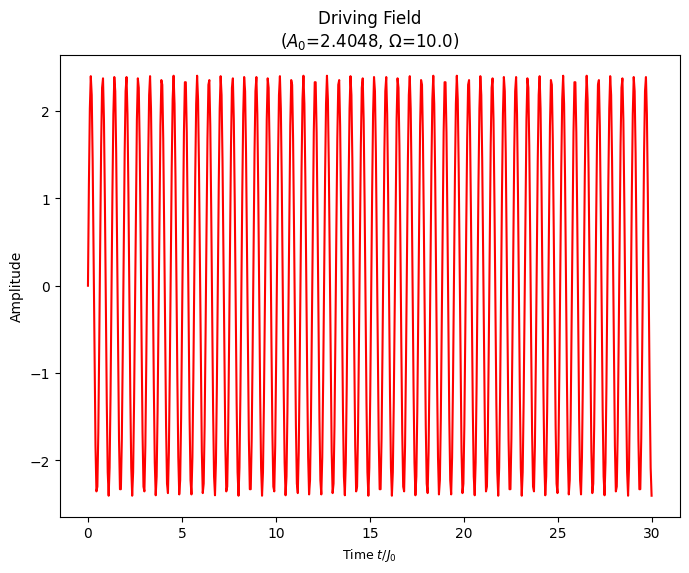

In [83]:
########
# Time #
########

N_t = 600
times = np.linspace(0.0, 30.0, N_t)
dt = times[1]-times[0]

###################
# Model Paramaters#
###################

L = 32

J0 = 1.0
U0 = 5.0
mu = - U0 

########################
# init Drive and Pulse #
########################

A0 = 2.40482
omega_drive = 10.0

A = A0 * np.sin(omega_drive * times)

plt.figure(figsize=(8, 6))
ax_main = plt.gca()
plt.plot(times, A, color='red', label=r'$A(t)$')
plt.ylabel(r'Amplitude')
plt.title(r'Driving Field' + '\n' + r'($A_0$={:.5}, $\Omega$={:.1f})'.format(A0, omega_drive))
plt.xlabel(r'Time $t/J_0$', fontsize=9)

plt.show()

In [84]:
#######################################
# DMRG, TDVP and model parameter dict #
#######################################

dmrg_params = {
    'mixer': True,
    'max_E_err': 1.e-6,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-6,
    },
}

tdvp_params = {
    'N_steps': 1,
    'dt': dt,
    'trunc_params': {
        'chi_max': 100, 
        'svd_min': 1.e-6,
    },
}

model_parameter = {
    'L': L,
    'J': J0,
    'U': U0,
    'mu': mu,
    'bc_MPS': 'finite',
    }

model_init = time_dependent_Hubbard(model_parameter)

lattice = model_init.lat

# Build product state: one up electron at L//4, one down electron at 3*L//4, rest empty
product_up = []
product_down = []
product_updown = []

for i in range(L):
    if i == L // 2:
        product_up.append('up')
        product_down.append('down')
        product_updown.append('full')
    else:
        product_up.append('empty')
        product_down.append('empty')
        product_updown.append('empty')

product_up = np.array(product_up, dtype=object).reshape(-1, 1)
product_down = np.array(product_down, dtype=object).reshape(-1, 1)
product_updown = np.array(product_updown, dtype=object).reshape(-1, 1)

psi_up = MPS.from_lat_product_state(lattice, product_up)
psi_down = MPS.from_lat_product_state(lattice, product_down)
psi_updown = MPS.from_lat_product_state(lattice, product_updown)

psis = [psi_up, psi_down, psi_updown]

results = np.zeros((3, 3, N_t, L), dtype=complex)

for i, psi in enumerate(psis):
    up_corr, down_corr, updown_corr = simulation(times, A, psi, model_parameter, tdvp_params) 
    
    results[i, :, :, :] = np.array([up_corr, down_corr, updown_corr])

print("Simulation completed.")

print("results of psi_up shape:", results[0].shape)
print("results of psi_down shape:", results[1].shape)
print("results of psi_updown shape:", results[2].shape)

Time step 1/600
Time step 31/600
Time step 61/600
Time step 91/600
Time step 121/600
Time step 151/600
Time step 181/600
Time step 211/600
Time step 241/600
Time step 271/600
Time step 301/600
Time step 331/600
Time step 361/600
Time step 391/600
Time step 421/600
Time step 451/600
Time step 481/600
Time step 511/600
Time step 541/600
Time step 571/600
Time step 1/600
Time step 31/600
Time step 61/600
Time step 91/600
Time step 121/600
Time step 151/600
Time step 181/600
Time step 211/600
Time step 241/600
Time step 271/600
Time step 301/600
Time step 331/600
Time step 361/600
Time step 391/600
Time step 421/600
Time step 451/600
Time step 481/600
Time step 511/600
Time step 541/600
Time step 571/600
Time step 1/600
Time step 31/600
Time step 61/600
Time step 91/600
Time step 121/600
Time step 151/600
Time step 181/600
Time step 211/600
Time step 241/600
Time step 271/600
Time step 301/600
Time step 331/600
Time step 361/600
Time step 391/600
Time step 421/600
Time step 451/600
Time st

Max imaginary part: 0.0


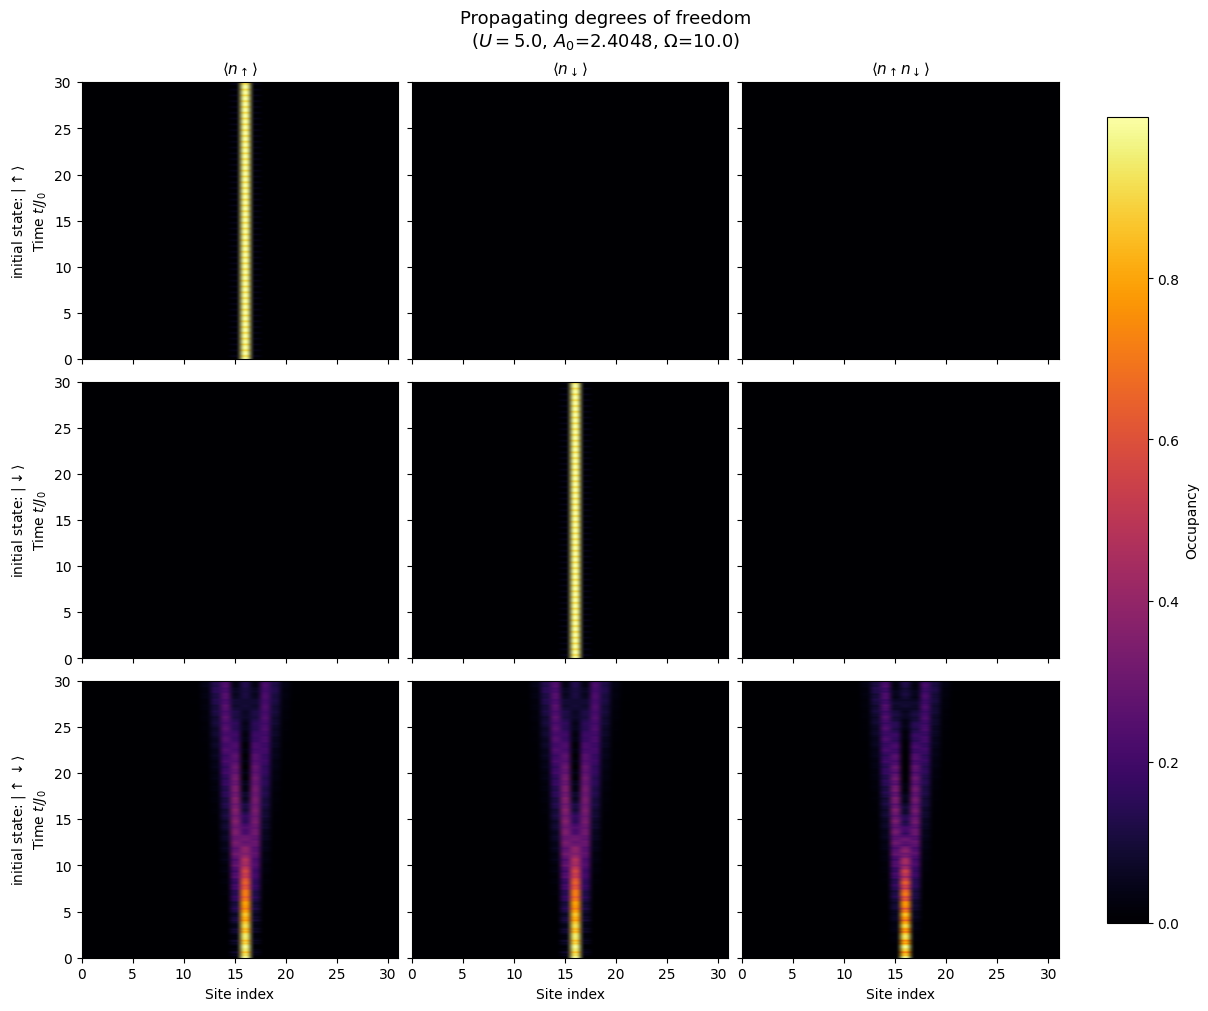

In [85]:
# 3x3 heatmaps:
# rows    -> initial state: psi_up, psi_down, psi_updown
# columns -> observable: up_corr, down_corr, updown_corr
# results shape = (3, 3, N_t, L)

print("Max imaginary part:", np.max(np.imag(results)))
data = np.real(results)  

row_titles = [r"initial state: $|\uparrow\rangle$", r"initial state: $|\downarrow\rangle$", r"initial state: $|\uparrow\downarrow\rangle$"]
col_titles = [
    r"$\langle n_\uparrow \rangle$",
    r"$\langle n_\downarrow \rangle$",
    r"$\langle n_\uparrow n_\downarrow \rangle$"
]

# Shared color scale across all panels
vmin = data.min()
vmax = data.max()

fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 10),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for i in range(3):        # initial state index
    for j in range(3):    # observable index
        im = axes[i, j].imshow(
            data[i, j],                      # shape (N_t, L)
            aspect="auto",
            cmap="inferno",
            origin="lower",
            extent=[0, L - 1, times[0], times[-1]],
            vmin=vmin,
            vmax=vmax
        )

        if i == 0:
            axes[i, j].set_title(col_titles[j], fontsize=11)
        if j == 0:
            axes[i, j].set_ylabel(f"{row_titles[i]}\nTime $t/J_0$", fontsize=10)
        if i == 2:
            axes[i, j].set_xlabel("Site index", fontsize=10)

cbar = fig.colorbar(im, ax=axes, shrink=0.92)
cbar.set_label("Occupancy", fontsize=10)

fig.suptitle(
    "Propagating degrees of freedom\n"
    + r"($U={}$, $A_0$={:.5}, $\Omega$={:.1f})".format(U0, A0, omega_drive),
    fontsize=13
)

plt.show()